# » `Dependencias`:

In [ ]:
# !pip install plotly
# !pip install sqlalchemy
# !pip install numpy
# !pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [3]:
def get_query_sql(query):
  try:
    df = pd.read_sql(query, connection)
    return df
  except:
    print('¡Ocurrió un error!')

## 3. Visualización de datos: `INF-NOV2024`

### 3.1 1. Se define como regla que, las dependencias de PUESTO DE CONTROL FRONTERIZO, deben excluir el transporte aéreo de sus registros de movimientos.

In [4]:
# Extracción
df_1 = pd.read_excel('./data/A1.xlsx')

<Axes: >

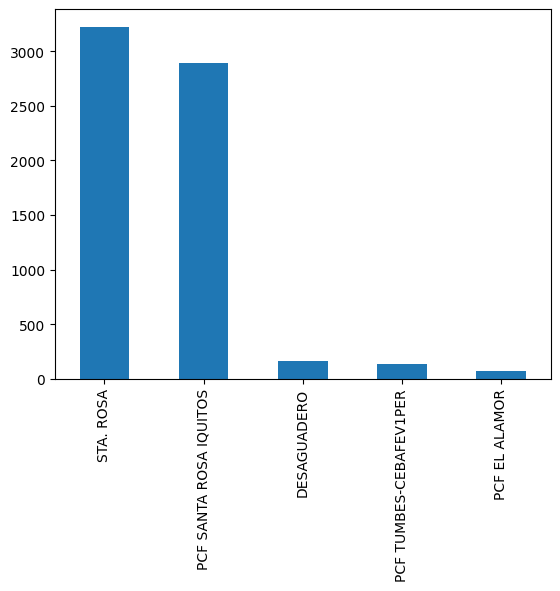

In [22]:
# Campos: ['Id Mov Migratorio','Fecha Control', 'Tipo Movimiento', 'Dependencia', 'Via Transporte']

df_1_1 = df_1.groupby(by=['Dependencia']).agg({ 'Id Mov Migratorio': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_1_1.plot.bar(legend=False, xlabel='')